# **Cloud-Native GRIB2: High-Performance Access with grib2io and VirtualiZarr**

This notebook demonstrates how to efficiently access GRIB2 data stored on AWS S3 without streaming the entire file. We'll leverage standard `.idx` sidecar files to build a virtual Xarray dataset instantly.

## Notebook Convention

Use the standard grib2io xarray backend interface or the standard zarr backend with fsspec reference filesystem.

## **The GRIB2 Challenge**

GRIB2 is a streaming format without a central metadata header. To create a virtual Zarr manifest, a standard scanner must read the file from start to finish to find message boundaries. For a multi-gigabyte file on S3, this normally means streaming all that data just to find the offsets.

### **The Solution: Standard sidecar Indices**
Public datasets (like NOAA GFS) often provide text-based `.idx` files alongside the GRIB files. `grib2io` can now parse these `.idx` files to extract byte offsets directly. This allows it to jump to each message and read only the small metadata headers (Sections 0-5), completely bypassing the large data payloads (Section 7) during the scanning phase.

In [7]:
import xarray as xr
import grib2io
import fsspec
from pathlib import Path
from virtualizarr import open_virtual_dataset, open_virtual_mfdataset
from virtualizarr.parsers import KerchunkJSONParser
from obstore.store import LocalStore, S3Store
from obspec_utils.registry import ObjectStoreRegistry
import s3fs
import json
import os

## **1. Locating GFS Data on S3**

We'll use a public GFS dataset from the NOAA Open Data Program on AWS. Note the presence of the `.idx` file.

In [2]:
# Example S3 path for a GFS file
s3_bucket = "noaa-gfs-bdp-pds"
s3_path = "gfs.20240501/00/atmos/gfs.t00z.pgrb2.0p25.f000"
s3_url = f"s3://{s3_bucket}/{s3_path}"
# Standard sidecar index: s3://noaa-gfs-bdp-pds/gfs.20240501/00/atmos/gfs.t00z.pgrb2.0p25.f000.idx

# Verify the key exists in the bucket before trying to build references.
fs = s3fs.S3FileSystem(anon=True)
if not fs.exists(f"{s3_bucket}/{s3_path}"):
    raise FileNotFoundError(f"S3 object not found: {s3_url}")

## **2. Building the Virtual Manifest via Index**

By leveraging the `.idx` file, `grib2io` maps out the chunks instantly. The `ReferenceGenerator` uses this to create a Kerchunk manifest.

In [3]:
from grib2io.kerchunk import ReferenceGenerator

# Stream directly from S3 (no local download).
gen = ReferenceGenerator(
    s3_url,
    storage_options={
        "anon": True,
        "default_fill_cache": False,
        "default_cache_type": "none",
        "default_block_size": 131072,
    },
)

# This step is now extremely fast as it avoids streaming data payloads.
manifest = gen.generate()

manifest_path = "gfs_s3_manifest.json"
with open(manifest_path, "w") as f:
    json.dump(manifest, f)

## **3. Ingesting into VirtualiZarr**

Load the S3-backed manifest into VirtualiZarr for metadata manipulation.

In [4]:
manifest_file = Path(manifest_path).resolve()
manifest_url = manifest_file.as_uri()

registry = ObjectStoreRegistry(
    {
        manifest_url: LocalStore(prefix=str(manifest_file.parent)),
        "s3://noaa-gfs-bdp-pds": S3Store(bucket="noaa-gfs-bdp-pds", skip_signature=True),
    }
)

vds = open_virtual_dataset(
    url=manifest_url,
    registry=registry,
    parser=KerchunkJSONParser(),
    loadable_variables=[],
)
display(vds)

<xarray.Dataset> Size: 3GB
Dimensions:                              (valid_time: 1, mean_sea_level: 1,
                                          y: 721, x: 1440, hybrid_level: 1,
                                          hybrid_level_2: 2,
                                          entire_atmosphere: 1, surface: 1,
                                          planetary_boundary_layer: 1,
                                          isobaric_surface: 41,
                                          ...
                                          highest_tropospheric_freezing_level: 1,
                                          pressure_difference_from_ground: 1,
                                          pressure_difference_from_ground_2: 3,
                                          sigma_level: 4, sigma_level_2: 1,
                                          pressure_difference_from_ground_3: 1,
                                          potential_vorticity_surface: 2)
Coordinates: (12/37)
    valid_time                           (valid_time) int64 8B ManifestArray<...
    mean_sea_level                       (mean_sea_level) float64 8B Manifest...
    latitude                             (y, x) float64 8MB ManifestArray<sha...
    longitude                            (y, x) float64 8MB ManifestArray<sha...
    hybrid_level                         (hybrid_level) float64 8B ManifestAr...
    hybrid_level_2                       (hybrid_level_2) float64 16B Manifes...
    ...                                   ...
    pressure_difference_from_ground      (pressure_difference_from_ground) float64 8B ManifestArray<shape=(1,), dtype=float64, chu...
    pressure_difference_from_ground_2    (pressure_difference_from_ground_2) float64 24B ManifestArray<shape=(3,), dtype=float64, ...
    sigma_level                          (sigma_level) float64 32B ManifestAr...
    sigma_level_2                        (sigma_level_2) float64 8B ManifestA...
    pressure_difference_from_ground_3    (pressure_difference_from_ground_3) float64 8B ManifestArray<shape=(1,), dtype=float64, c...
    potential_vorticity_surface          (potential_vorticity_surface) float64 16B ManifestArray<shape=(2,), dtype=float64, chunks...
Dimensions without coordinates: y, x
Data variables: (12/125)
    PRMSL                                (valid_time, mean_sea_level, y, x) float32 4MB ManifestArray<shape=(1, 1, 721, 1440), dtype=float32, chunks=(1, 1, ...
    CLMR                                 (valid_time, hybrid_level, y, x) float32 4MB ManifestArray<shape=(1, 1, 721, 1440), dtype=float32, chunks=(1, 1, 72...
    ICMR                                 (valid_time, hybrid_level, y, x) float32 4MB ManifestArray<shape=(1, 1, 721, 1440), dtype=float32, chunks=(1, 1, 72...
    RWMR                                 (valid_time, hybrid_level, y, x) float32 4MB ManifestArray<shape=(1, 1, 721, 1440), dtype=float32, chunks=(1, 1, 72...
    SNMR                                 (valid_time, hybrid_level, y, x) float32 4MB ManifestArray<shape=(1, 1, 721, 1440), dtype=float32, chunks=(1, 1, 72...
    GRLE                                 (valid_time, hybrid_level, y, x) float32 4MB ManifestArray<shape=(1, 1, 721, 1440), dtype=float32, chunks=(1, 1, 72...
    ...                                   ...
    UGRD_8                               (valid_time, potential_vorticity_surface, y, x) float32 8MB ManifestArray<shape=(1, 2, 721, 1440), dtype=float32, c...
    VGRD_8                               (valid_time, potential_vorticity_surface, y, x) float32 8MB ManifestArray<shape=(1, 2, 721, 1440), dtype=float32, c...
    TMP_8                                (valid_time, potential_vorticity_surface, y, x) float32 8MB ManifestArray<shape=(1, 2, 721, 1440), dtype=float32, c...
    HGT_7                                (valid_time, potential_vorticity_surface, y, x) float32 8MB ManifestArray<shape=(1, 2, 721, 1440), dtype=float32, c...
    PRES_4                               (valid_time, potential_vorticity_

## **4. Targeted Data Access**

Use standard xarray interfaces to load data:

- Open the remote manifest via standard `zarr` engine and `fsspec` Reference-FS:
  ```python
  fs = fsspec.filesystem('reference', fo=manifest_path, asynchronous=True, remote_options={'anon': True, 'asynchronous': True})
  mapper = fs.get_mapper('')
  ds = xr.open_dataset(mapper, engine='zarr', consolidated=False)
  ```
- Open the remote GRIB2 file directly using the `grib2io` backend:
  ```python
  ds = xr.open_dataset(s3_url, engine='grib2io', storage_options={'anon': True})
  ```

In [5]:
# ── Option A: Open the pre-built manifest using the standard zarr engine and fsspec Reference-FS ─────────
fs = fsspec.filesystem(
    "reference",
    fo=manifest_path,
    asynchronous=True,
    remote_options={"anon": True, "asynchronous": True},
)
mapper = fs.get_mapper("")
ds = xr.open_dataset(mapper, engine="zarr", consolidated=False)

# ── Option B: Open the original remote GRIB2 file directly via grib2io backend ───────────────
# ds = xr.open_dataset(s3_url, engine="grib2io", storage_options={"anon": True})

display(ds)

<xarray.Dataset> Size: 3GB
Dimensions:                              (valid_time: 1, mean_sea_level: 1,
                                          y: 721, x: 1440, hybrid_level: 1,
                                          hybrid_level_2: 2,
                                          entire_atmosphere: 1, surface: 1,
                                          planetary_boundary_layer: 1,
                                          isobaric_surface: 41,
                                          ...
                                          highest_tropospheric_freezing_level: 1,
                                          pressure_difference_from_ground: 1,
                                          pressure_difference_from_ground_2: 3,
                                          sigma_level: 4, sigma_level_2: 1,
                                          pressure_difference_from_ground_3: 1,
                                          potential_vorticity_surface: 2)
Coordinates: (12/37)
  * valid_time                           (valid_time) datetime64[ns] 8B 2024-...
  * mean_sea_level                       (mean_sea_level) float64 8B nan
    latitude                             (y, x) float64 8MB ...
    longitude                            (y, x) float64 8MB ...
  * hybrid_level                         (hybrid_level) float64 8B 1.0
  * hybrid_level_2                       (hybrid_level_2) float64 16B 1.0 2.0
    ...                                   ...
  * pressure_difference_from_ground      (pressure_difference_from_ground) float64 8B ...
  * pressure_difference_from_ground_2    (pressure_difference_from_ground_2) float64 24B ...
  * sigma_level                          (sigma_level) float64 32B 0.33 ... 0.72
  * sigma_level_2                        (sigma_level_2) float64 8B 0.995
  * pressure_difference_from_ground_3    (pressure_difference_from_ground_3) float64 8B ...
  * potential_vorticity_surface          (potential_vorticity_surface) float64 16B ...
Dimensions without coordinates: y, x
Data variables: (12/125)
    PRMSL                                (valid_time, mean_sea_level, y, x) float32 4MB ...
    CLMR                                 (valid_time, hybrid_level, y, x) float32 4MB ...
    ICMR                                 (valid_time, hybrid_level, y, x) float32 4MB ...
    RWMR                                 (valid_time, hybrid_level, y, x) float32 4MB ...
    SNMR                                 (valid_time, hybrid_level, y, x) float32 4MB ...
    GRLE                                 (valid_time, hybrid_level, y, x) float32 4MB ...
    ...                                   ...
    UGRD_8                               (valid_time, potential_vorticity_surface, y, x) float32 8MB ...
    VGRD_8                               (valid_time, potential_vorticity_surface, y, x) float32 8MB ...
    TMP_8                                (valid_time, potential_vorticity_surface, y, x) float32 8MB ...
    HGT_7                                (valid_time, potential_vorticity_surface, y, x) float32 8MB ...
    PRES_4                               (valid_time, potential_vorticity_surface, y, x) float32 8MB ...
    VWSH_1                               (valid_time, potential_vorticity_surface, y, x) float32 8MB ...

In [ ]:
vds

In [6]:
if "TMP" in ds.data_vars:
    try:
        data = ds.TMP.isel(valid_time=0, isobaric_surface=0, y=slice(100, 200), x=slice(100, 200)).compute()
        print(f"shape: {data.shape}, min: {float(data.min()):.2f} K, max: {float(data.max()):.2f} K")
        display(data)
    except Exception as e:
        print(f"Failed to compute TMP: {e}")
elif "PRMSL" in ds.data_vars:
    data = ds.PRMSL.isel(valid_time=0, mean_sea_level=0, y=slice(100, 200), x=slice(100, 200)).compute()
    print(f"shape: {data.shape}, min: {float(data.min()):.2f} Pa, max: {float(data.max()):.2f} Pa")
    display(data)

shape: (100, 100), min: 171.92 K, max: 185.92 K


<xarray.DataArray 'TMP' (y: 100, x: 100)> Size: 40kB
array([[177.80804, 177.71805, 177.63805, ..., 171.93805, 171.92804,
        171.93805],
       [177.88805, 177.80804, 177.71805, ..., 171.95804, 171.93805,
        171.91805],
       [177.97804, 177.89804, 177.79805, ..., 171.98804, 171.94804,
        171.91805],
       ...,
       [183.69804, 183.64804, 183.61804, ..., 185.63805, 185.63805,
        185.61804],
       [183.86804, 183.83804, 183.81804, ..., 185.74805, 185.72804,
        185.69804],
       [184.00804, 184.01804, 184.02805, ..., 185.80804, 185.78804,
        185.74805]], shape=(100, 100), dtype=float32)
Coordinates:
    latitude          (y, x) float64 80kB 65.0 65.0 65.0 ... 40.25 40.25 40.25
    longitude         (y, x) float64 80kB 25.0 25.25 25.5 ... 49.25 49.5 49.75
    valid_time        datetime64[ns] 8B 2024-05-01
    isobaric_surface  float64 8B 1.0
Dimensions without coordinates: y, x
Attributes:
    discipline:                0
    parameterCategory:         0
    parameterNumber:           0
    typeOfFirstFixedSurface:   100
    valueOfFirstFixedSurface:  1.0
    valid_time:                2024-05-01T00:00:00
    shortName:                 TMP
    fullName:                  Temperature
    units:                     K

In [ ]:
import pandas as pd
BUCKET = "noaa-gfs-bdp-pds"
YEAR = "2025"  # any YYYY present in the bucket
GRID = "0p25"  # 0.25-degree global grid
CYCLE = "00"  # 00Z analysis
FORECAST = "f000"  # analysis hour (zero-lead)

# More tolerant network settings for remote NOAA S3 reads via s3fs/botocore.
storage_options = {
    "anon": True,
    "config_kwargs": {
        "connect_timeout": 30,
        "read_timeout": 120,
        "retries": {"max_attempts": 10, "mode": "adaptive"},
    },
}

# Filter to 2-metre temperature only — skips all other variables during scanning.
# typeOfFirstFixedSurface=103 -> "height above ground (m)"; level=2 -> 2 m
T2M_FILTERS = {"shortName": "TMP", "typeOfFirstFixedSurface": 103}

# Build URLs for the selected year.
year_start = pd.to_datetime(f"{YEAR}-01-01")
year_end = pd.to_datetime(f"{YEAR}-12-31")
dates = pd.date_range(year_start, year_end, freq="D")
PERIOD_LABEL = YEAR
urls = [f"s3://{BUCKET}/gfs.{d.strftime('%Y%m%d')}/{CYCLE}/atmos/gfs.t{CYCLE}z.pgrb2.{GRID}.{FORECAST}" for d in dates]
urls2 = [f"s3://{BUCKET}/gfs.{d.strftime('%Y%m%d')}/{CYCLE}/atmos/gfs.t{CYCLE}z.pgrb2.{GRID}.f120" for d in dates]
print(f"Period: {PERIOD_LABEL}  ({len(urls)} files)")
print("First:", urls[0])
print("Last: ", urls[-1])

Period: 2025  (365 files)
First: s3://noaa-gfs-bdp-pds/gfs.20250101/00/atmos/gfs.t00z.pgrb2.0p25.f000
Last:  s3://noaa-gfs-bdp-pds/gfs.20251231/00/atmos/gfs.t00z.pgrb2.0p25.f000


## **5. Multiple files → one virtual dataset**

To combine many GRIB2 files into a single time series, pass the **whole list of
URLs** to `ReferenceGenerator`. It scans every file's `.idx` sidecar in a thread
pool (`max_workers`) — reading only header bytes — and emits **one combined
Kerchunk manifest** already concatenated along `valid_time`.

This is far faster than `xr.open_mfdataset(..., engine="grib2io")` for large file
counts: that path dispatches each open to Dask workers and pickles every
`s3fs`-backed dataset back to the client, which stalls for minutes. Here, a full
year (365 files) builds in ~3 seconds.


In [12]:
import time

# Build ONE combined manifest for all files. max_workers uses a thread pool
# to scan the .idx sidecars concurrently (header bytes only, no payloads).
t0 = time.perf_counter()
gen_year = ReferenceGenerator(
    urls,
    filters=T2M_FILTERS,
    storage_options={"anon": True},
    max_workers=16,
)
manifest_year = gen_year.generate()
print(f"Built manifest for {len(urls)} files in {time.perf_counter() - t0:.2f}s")

# Persist and open the combined manifest as a single lazy dataset.
year_manifest_path = "gfs_year_t2m_manifest.json"
with open(year_manifest_path, "w") as f:
    json.dump(manifest_year, f)

fs_year = fsspec.filesystem(
    "reference",
    fo=year_manifest_path,
    asynchronous=True,
    remote_options={"anon": True, "asynchronous": True},
)
ds_year = xr.open_dataset(fs_year.get_mapper(""), engine="zarr", consolidated=False)
print("dims:", dict(ds_year.sizes))
print("valid_time:", str(ds_year.valid_time.values[0]), "->", str(ds_year.valid_time.values[-1]))
display(ds_year)


Built manifest for 365 files in 2.69s
dims: {'valid_time': 365, 'height_above_ground': 3, 'y': 721, 'x': 1440}
valid_time: 2025-01-01T00:00:00.000000000 -> 2025-12-31T00:00:00.000000000


<xarray.Dataset> Size: 5GB
Dimensions:              (valid_time: 365, height_above_ground: 3, y: 721,
                          x: 1440)
Coordinates:
  * valid_time           (valid_time) datetime64[ns] 3kB 2025-01-01 ... 2025-...
  * height_above_ground  (height_above_ground) float64 24B 2.0 80.0 100.0
    latitude             (y, x) float64 8MB ...
    longitude            (y, x) float64 8MB ...
Dimensions without coordinates: y, x
Data variables:
    TMP                  (valid_time, height_above_ground, y, x) float32 5GB ...

In [13]:
# Data stays lazy until computed. Only the bytes needed are fetched from S3.
t2m = ds_year["TMP"].isel(height_above_ground=0)  # 2 m level

t0 = time.perf_counter()
jan_mean = float(t2m.isel(valid_time=slice(0, 31)).mean().compute()) - 273.15
print(f"January global-mean 2 m T = {jan_mean:.2f} degC  ({time.perf_counter() - t0:.1f}s)")


January global-mean 2 m T = 4.08 degC  (1.8s)


## 6. Global map — mean T2M for the month

`.mean("valid_time")` is computed first (still lazy), then `.compute()` fetches
only the bytes needed to materialise those values.

Computing monthly mean ...


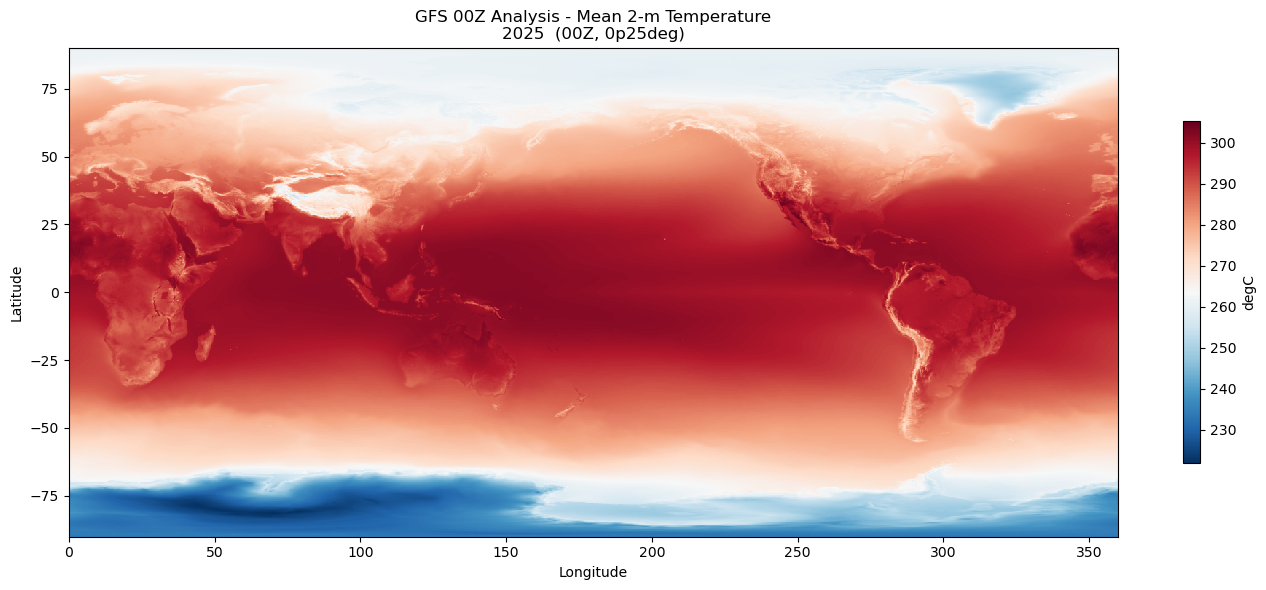

In [16]:
print("Computing monthly mean ...")
from matplotlib import pyplot as plt

t2m_mean = t2m.mean("valid_time").compute()

# ---- plot ----------------------------------------------------------------
lats = t2m_mean.coords.get("latitude", t2m_mean.coords.get("y", None))
lons = t2m_mean.coords.get("longitude", t2m_mean.coords.get("x", None))

fig, ax = plt.subplots(figsize=(14, 6))
if lats is not None and lons is not None:
    pcm = ax.pcolormesh(lons, lats, t2m_mean.values, cmap="RdBu_r", shading="auto")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
else:
    pcm = ax.imshow(t2m_mean.values, origin="upper", cmap="RdBu_r", aspect="auto")
    ax.set_xlabel("x index")
    ax.set_ylabel("y index")

plt.colorbar(pcm, ax=ax, label="degC", shrink=0.7)
ax.set_title(f"GFS 00Z Analysis - Mean 2-m Temperature\n{PERIOD_LABEL}  (00Z, {GRID}deg)")
plt.tight_layout()
plt.show()

## 7. Point time series

Select the nearest grid point to a location of interest and plot the daily
T2M over the month.  Only the bytes for those specific grid-point chunks
are fetched.

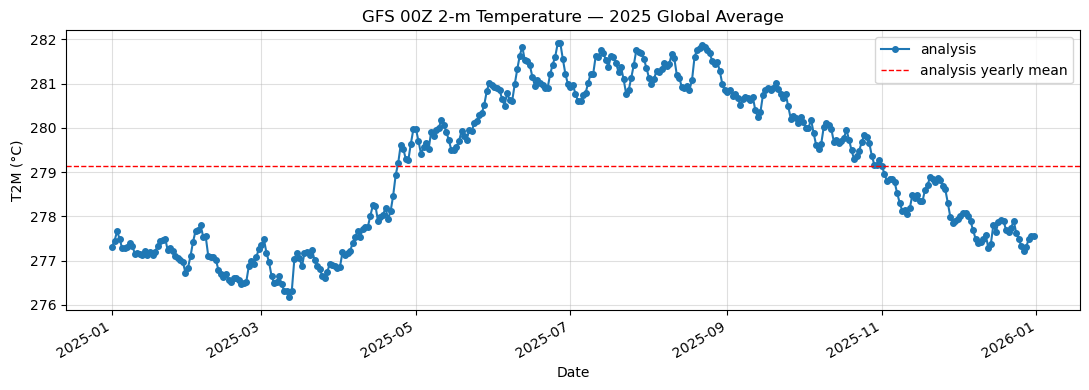


Yearly mean: 279.13 °C
Min: 276.18 °C  on 2025-03-12
Max: 281.92 °C  on 2025-06-27


/opt/homebrew/Caskroom/miniforge/base/envs/grib2io/lib/python3.14/site-packages/xarray/core/dataarray.py:6318: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)
/opt/homebrew/Caskroom/miniforge/base/envs/grib2io/lib/python3.14/site-packages/xarray/core/dataarray.py:6439: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmax(dim, axis, keep_attrs, skipna)


In [17]:
# Location of interest (change as desired)
TARGET_LAT = 40.71  # New York City
TARGET_LON = -74.01  # (negative = West)

lats = t2m.coords.get("latitude", t2m.coords.get("y", None))
lons = t2m.coords.get("longitude", t2m.coords.get("x", None))

# Compute 1-D global-mean time series with moderate time chunking.
ts = t2m.chunk({"valid_time": 14}).mean("x").mean("y").compute()
times = pd.to_datetime(ts.coords["valid_time"].values)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(times, ts.values.ravel(), marker="o", linewidth=1.5, markersize=4, label="analysis")
ax.axhline(float(ts.mean()), color="red", linestyle="--", linewidth=1, label="analysis yearly mean")
ax.set_xlabel("Date")
ax.set_ylabel("T2M (\u00b0C)")
ax.set_title(f"GFS 00Z 2-m Temperature \u2014 {PERIOD_LABEL} Global Average")
ax.legend()
ax.grid(alpha=0.4)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f"\nYearly mean: {float(ts.mean()):.2f} \u00b0C")
print(f"Min: {float(ts.min()):.2f} \u00b0C  on {times[int(ts.argmin())].date()}")
print(f"Max: {float(ts.max()):.2f} \u00b0C  on {times[int(ts.argmax())].date()}")